In [3]:
import pandas
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'


In [4]:
directory = "./thauera-files/ThaueraPaper/"

## Aerobic

In [5]:
CN = pandas.read_csv("{}/CNRatioAerobic.csv".format(directory),header=None)
Data = pandas.read_csv("{}/PolymerPerCarbonAerobic2.csv".format(directory),header=None)
sources = pandas.read_csv("{}/carbonAerobic.txt".format(directory),index_col=0,header=None).index.to_list()

In [6]:
Data.index = sources
CN.index = sources

In [7]:
DataAerobic = Data.copy()
CNAerobic = CN.copy()

In [8]:
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#ffff33','#a65628']

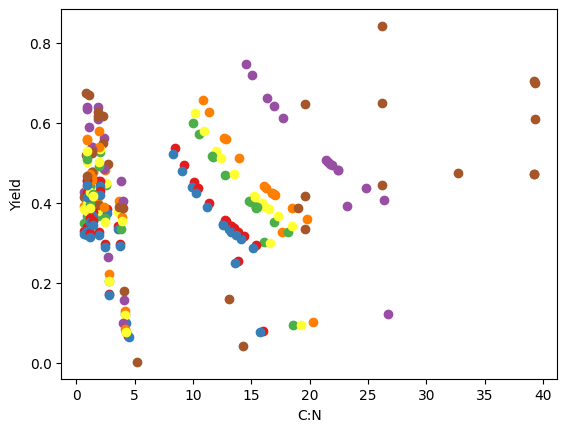

In [9]:
for i in CN.index:
    for idx,j in enumerate(CN.columns):
        plt.plot(CN.loc[i,j],Data.loc[i,j],"o",color=colors[idx])
plt.xlabel("C:N")
plt.ylabel("Yield")
plt.savefig("./figures/CN-aerobic.svg",format="SVG")

<Axes: >

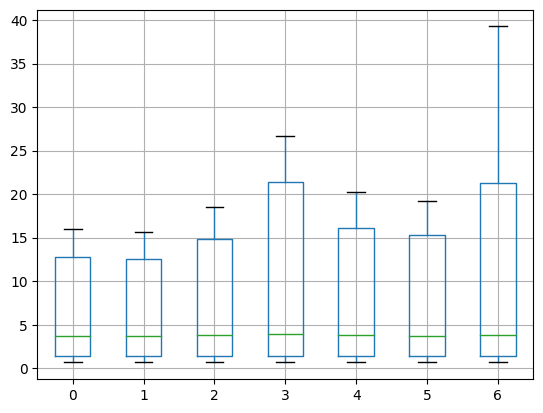

In [46]:
CN.boxplot()

In [47]:
[i for i in CN[CN<5].dropna(axis=0).index.to_list()]

['akg_e',
 'ala__D_e',
 'ala__L_e',
 'asn__L_e',
 'glc__D_e',
 'glcn_e',
 'glu__L_e',
 'glyc_e',
 'guln__L_e',
 'his__L_e',
 'ins_e',
 'lac__L_e',
 'leu__L_e',
 'pro__L_e',
 'ptrc_e',
 'pyr_e',
 'ser__L_e',
 'succ_e',
 'thr__L_e',
 'urcan_e']

In [48]:
[i for i in CN[((CN>10) & (CN<20)).any(axis=1)].index.to_list()]

['4abut_e',
 '4hphac_e',
 'ac_e',
 'acon_C_e',
 'asp__L_e',
 'balamd_e',
 'bhb_e',
 'btd_RR_e',
 'cit_e',
 'etha_e',
 'orn_e',
 'peamn_e',
 'phe__L_e',
 'ppa_e',
 'uri_e']

## Anaerobic

In [10]:
CN = pandas.read_csv("{}/CNRatioAnaerobic.csv".format(directory),header=None)
Data = pandas.read_csv("{}/PolymerPerCarbonAnaerobic2.csv".format(directory),header=None)
sources = pandas.read_csv("{}/carbonAnaerobic.txt".format(directory),index_col=0,header=None).index.to_list()

In [11]:
Data.index = sources
CN.index = sources

In [12]:
DataAnaerobic = Data.copy()
CNAnaerobic = CN.copy()

In [13]:
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#ffff33','#a65628']

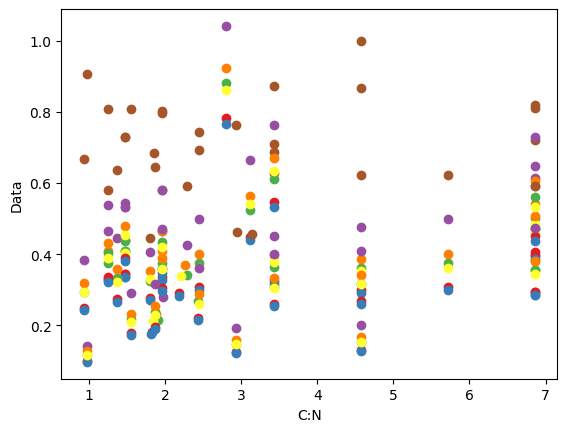

In [14]:
for i in CN.index:
    for idx,j in enumerate(CN.columns):
        plt.plot(CN.loc[i,j],Data.loc[i,j],"o",color=colors[idx])
plt.xlabel("C:N")
plt.ylabel("Data")
plt.savefig("./figures/CN-anaerobic.svg",format="SVG")


<Axes: >

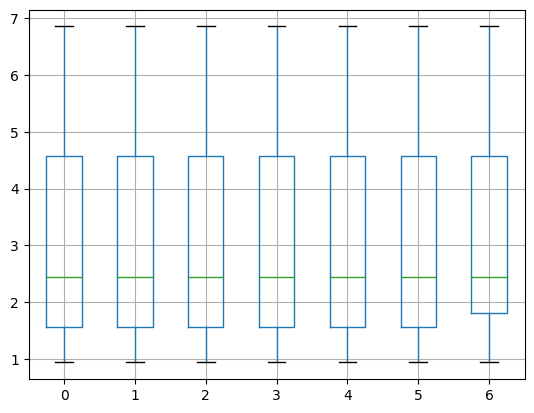

In [15]:
CN.boxplot()

## vs

In [16]:
mets = set(DataAerobic.index) & set(DataAnaerobic.index)

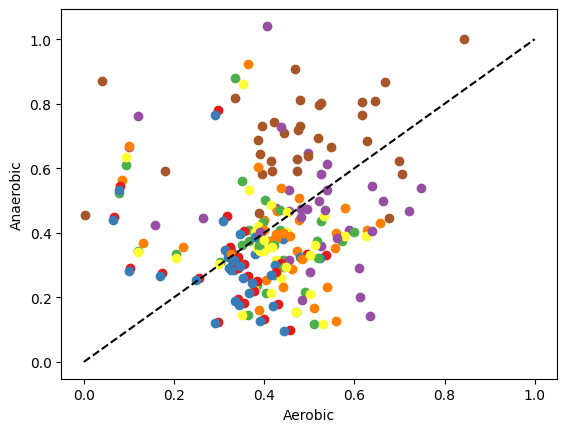

In [18]:
for i in mets:
    for idx,j in enumerate(DataAerobic.columns):
        plt.plot(DataAerobic.loc[i,j],DataAnaerobic.loc[i,j],"o",color=colors[idx])
plt.plot([0,1],[0,1],linestyle="--",color="black")
plt.xlabel("Aerobic")
plt.ylabel("Anaerobic")
plt.savefig("./figures/Yield-aerobic-vs-anaerobic.svg",format="SVG")


In [19]:
mets = set(CNAerobic.index) & set(CNAnaerobic.index)

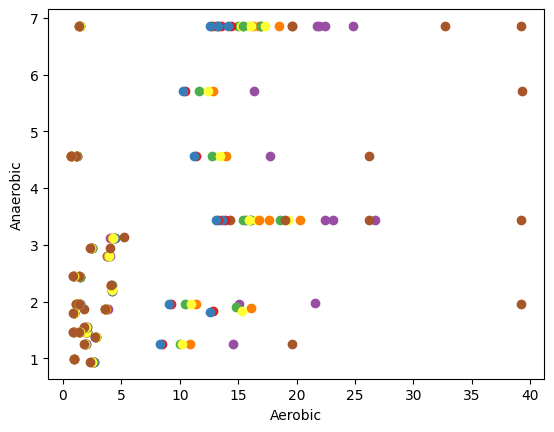

In [20]:
for i in mets:
    for idx,j in enumerate(CNAerobic.columns):
        plt.plot(CNAerobic.loc[i,j],CNAnaerobic.loc[i,j],"o",color=colors[idx])
# plt.plot([0,1],[0,1],linestyle="--",color="black")
plt.xlabel("Aerobic")
plt.ylabel("Anaerobic")
plt.savefig("./figures/CN-aerobic-vs-anaerobic.svg",format="SVG")


In [27]:
CNAerobic

,0,1,2,3,4,5,6
4abut_e,13.301204,13.067240,15.405933,22.450919,16.774894,15.892815,39.242609
4hphac_e,10.087017,9.922407,11.687465,16.953048,12.697800,11.952470,39.266257
ac_e,12.768190,12.553425,14.978320,21.778995,16.291245,15.243816,32.720039
acon_C_e,10.439392,10.256912,11.602742,16.361141,12.802983,12.397005,39.268385
akg_e,1.445471,1.448695,1.418320,1.373584,1.406342,1.416007,1.375890
ala__D_e,1.445471,1.448695,1.418320,1.373584,1.406342,1.416007,1.375890
ala__L_e,0.913684,0.914795,0.904520,0.889067,0.900523,0.903651,0.886167
asn__L_e,1.956421,1.961520,1.914882,1.846922,1.897054,1.910990,1.834513
asp__L_e,9.210658,9.066736,10.480935,15.068766,11.391523,10.973603,39.233403
balamd_e,14.396939,14.139015,16.944159,24.816080,18.519327,17.276025,19.636480


In [21]:
from notebooks.save import execute

In [22]:
date = "2024_05_10"
out,err=execute("jupyter nbconvert --to html 5.CN.ipynb --output-dir=./notebooks/ --output 5.CN-{}".format(date))

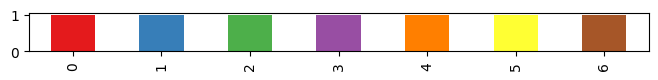

In [61]:
pandas.Series({k:1 for k in CN.columns}).plot.bar(color=colors,figsize=(8,0.5))
plt.savefig("./figures/CN-colorbar.svg",format="SVG")